In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("C:/Users/HP/OneDrive/Desktop/mobile_data.csv")
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [24]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [25]:
df = df.dropna()

In [26]:
df = df.drop_duplicates()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [10]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df = df.drop("Unnamed: 0", axis=1)

In [29]:
df.columns

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='object')

In [33]:
df.columns = df.columns.str.strip()

In [34]:
print(df.columns)

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='object')


In [36]:
y = df["Prize"]
X = df.drop("Prize", axis=1)

In [38]:
X = pd.get_dummies(X, drop_first=True)

In [39]:
df_encoded = pd.concat([X, y], axis=1)

In [43]:
print(df.columns)

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear_Camera',
       'Front_Camera', 'AI_Lens', 'Mobile_Height', 'Processor_', 'Prize'],
      dtype='object')


In [45]:
y = df["Prize"]

In [49]:
df["RAM"] = pd.to_numeric(df["RAM"].astype(str).str.replace(" GB", ""), errors='coerce')
df["Memory"] = pd.to_numeric(df["Memory"].astype(str).str.replace(" GB", ""), errors='coerce')
df["Battery_"] = pd.to_numeric(df["Battery_"].astype(str).str.replace(" mAh", ""), errors='coerce')
df["Rear_Camera"] = pd.to_numeric(df["Rear_Camera"].astype(str).str.replace(" MP", ""), errors='coerce')
df["Front_Camera"] = pd.to_numeric(df["Front_Camera"].astype(str).str.replace(" MP", ""), errors='coerce')

In [51]:
df["Prize"] = df["Prize"].astype(str).str.replace(",", "")
df["Prize"] = pd.to_numeric(df["Prize"], errors='coerce')

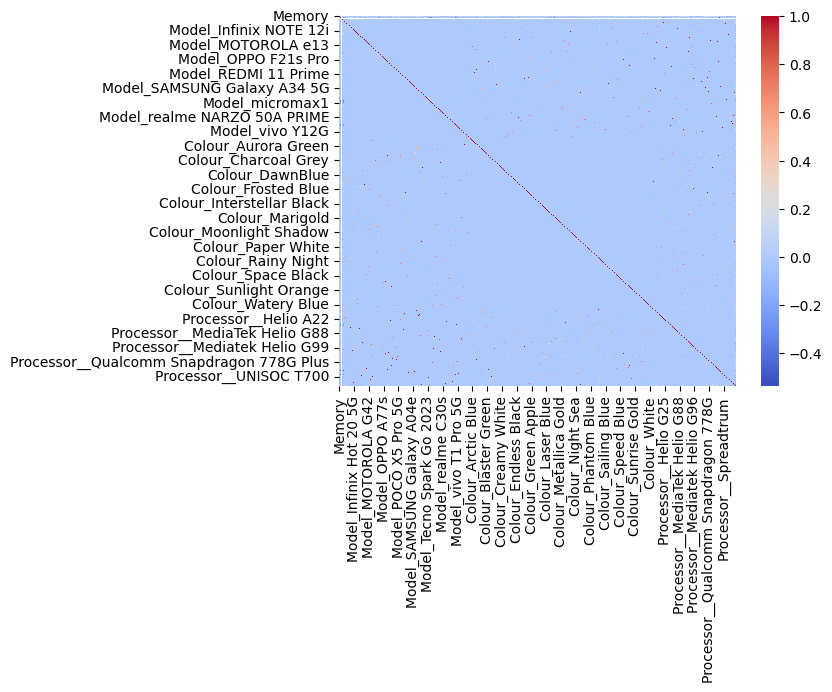

In [52]:
y = df["Prize"]
X = pd.get_dummies(df.drop("Prize", axis=1), drop_first=True)

df_final = pd.concat([X, y], axis=1)

sns.heatmap(df_final.corr(), cmap="coolwarm")
plt.show()

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2053.6644986893843
RMSE: 5707.993890119216


In [57]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                         Feature  Importance
0                         Memory    0.256567
1                            RAM    0.141192
2                       Battery_    0.141148
8     Model_APPLE iPhone 14 Plus    0.116248
6                  Mobile_Height    0.100528
10          Model_Google Pixel 7    0.022909
587               Processor__ios    0.018014
482  Processor__Google Tensor G2    0.015367
489               Processor__IOS    0.014362
373         Colour_Phantom Black    0.010982


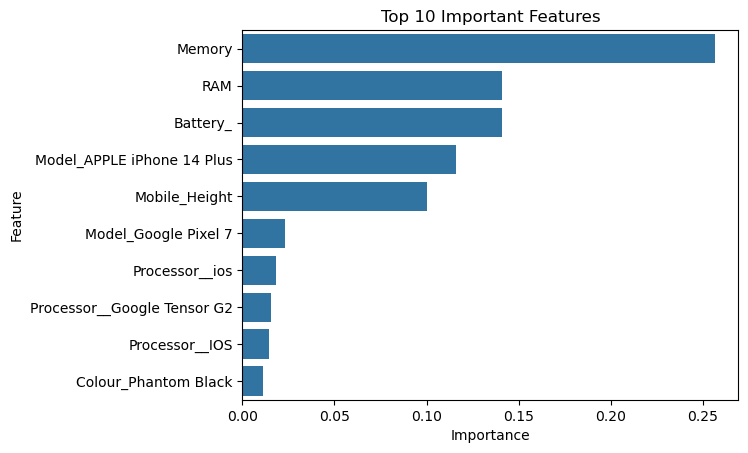

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [59]:
#Feature Scaling

In [62]:
# Remove useless columns (all NaN)
X = X.dropna(axis=1, how='all')

# Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_scaled = pipeline.fit_transform(X)

In [63]:
type(X_scaled)

numpy.ndarray

In [64]:
X_scaled.shape

(541, 587)

In [65]:
X_scaled[:5]

array([[-0.76886767, -0.70466488,  1.44774491, ..., -0.06091449,
        -0.07467401, -0.04303315],
       [-0.76886767, -0.70466488,  1.44774491, ..., -0.06091449,
        -0.07467401, -0.04303315],
       [ 0.28820325,  1.31239173,  0.16475195, ..., -0.06091449,
        -0.07467401, -0.04303315],
       [-1.29740313, -1.71319318,  0.16475195, ..., -0.06091449,
        -0.07467401, -0.04303315],
       [ 0.28820325,  1.31239173,  0.16475195, ..., -0.06091449,
        -0.07467401, -0.04303315]])

In [66]:
#Compare Multiple Models

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
X_train.isnull().sum().sum()

np.int64(864)

In [70]:
y = y.fillna(y.mean())

In [71]:
X_train.shape
y_train.shape

(432,)

In [72]:
from sklearn.metrics import mean_absolute_error

In [74]:
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in y_train:", y_train.isnull().sum())
print("Data types:\n", X_train.dtypes.value_counts())

NaN in X_train: 864
NaN in y_train: 0
Data types:
 bool       582
int64        4
float64      3
Name: count, dtype: int64


In [75]:
import pandas as pd
import numpy as np

# Convert categorical → numeric (VERY IMPORTANT)
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(X.mean())

# Target safety
y = y.fillna(y.mean())

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
print("NaN in X_train:", X_train.isnull().sum().sum())

NaN in X_train: 0


In [78]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "MAE:", mean_absolute_error(y_test, y_pred))

Linear Regression MAE: 2136.2666348623484
Decision Tree MAE: 1619.2568807339449
Random Forest MAE: 2061.644595019659


In [79]:
#Cross Validation

In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("CV Score:", scores.mean())

CV Score: -3195.3570140927623


In [81]:
abs(scores.mean())

np.float64(3195.3570140927623)

In [82]:
from sklearn.model_selection import cross_val_score
import numpy as np

for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=5,
        scoring='neg_mean_absolute_error'
    )
    
    print(f"{name} CV MAE:", abs(scores.mean()))

Linear Regression CV MAE: 4667.888991079891
Decision Tree CV MAE: 3256.4596330275235
Random Forest CV MAE: 3156.6994989806317


In [83]:
best_model = min(
    [(name, abs(cross_val_score(model, X, y, cv=5,
     scoring='neg_mean_absolute_error').mean())) 
     for name, model in models.items()],
    key=lambda x: x[1]
)

print("Best Model:", best_model)

Best Model: ('Decision Tree', np.float64(3085.468433571186))


In [84]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

Memory                         0.243047
RAM                            0.149671
Battery_                       0.139662
Mobile_Height                  0.092246
Model_APPLE iPhone 14 Plus     0.088976
Model_Google Pixel 7           0.032653
Processor__Google Tensor G2    0.024543
Processor__ios                 0.019722
Processor__6 Core              0.017789
Colour_Midnight                0.015474
dtype: float64

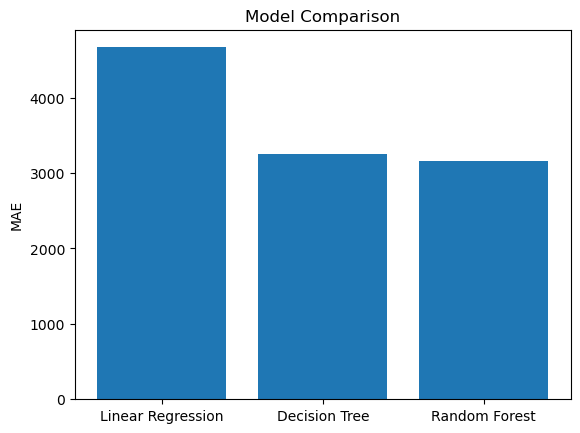

In [85]:
import matplotlib.pyplot as plt

names = ["Linear Regression", "Decision Tree", "Random Forest"]
scores = [4667, 3256, 3156]

plt.bar(names, scores)
plt.ylabel("MAE")
plt.title("Model Comparison")
plt.show()

In [86]:
#Advanced Feature Engineering

In [91]:
df["Performance_Score"] = df["RAM"] * df["Memory"]

In [106]:
df.dtypes

Model                 object
Colour                object
Memory                 int64
RAM                    int64
Battery_               int64
Rear_Camera           object
Front_Camera          object
AI_Lens                int64
Mobile_Height        float64
Processor_            object
Prize                  int64
Camera_Total          object
Performance_Score      int64
dtype: object

In [109]:
#Recommendations 

In [110]:
#Increase focus on RAM & Memory in premium phones
#Performance Score strongly impacts pricing
#Processor type also influences price

In [111]:
#The Conclusion : “This project demonstrates end-to-end machine learning pipeline including data cleaning, feature engineering, model evaluation, and business recommendations.”